# Chapter 02: Length Spaces

**Source Span.** Printed pages 25-58; physical source pages 40-73. The source is used only for structure, terminology, theorem orientation, and page spans. All prose, code, examples, and generated artifacts are original.

## Chapter Goal

This notebook rebuilds **Length Spaces** as a standalone visual lesson for A Course in Metric Geometry. The working language is metric spaces, length structures, comparison geometry, and curvature bounds. The purpose is to turn definitions into inspectable objects, theorem hypotheses into explicit constraints, and conclusions into checks that a learner can run.

## Translation Guide

Read the chapter vocabulary as computational handles. Local objects become arrays or symbolic records, transformations become functions, and invariants become diagnostics. The notebook keeps proof ideas visible through diagrams, finite models, and sanity checks rather than asking the learner to trust a picture.

## Route Through the Unit

1. Identify the chapter object and the allowed transformations. 2. Build a compact visual model. 3. Attach a check to the model. 4. Vary a parameter in the lab. 5. Confirm artifacts and numeric diagnostics.

## Concept Inventory

Length structures, induced intrinsic metrics, shortest paths, length measure, and speed.

The span is treated as a sequence of constructions: first the objects, then the maps between them, then the obstruction or invariant that controls the main theorem. The example is intentionally small enough to execute quickly, but the labels and checks mirror the chapter's mathematical role.

## Library Routing

Matplotlib is used for durable static geometry, a local HTML artifact supplies a lightweight parameter lab, and JSON records the invariant check. Richer libraries can be substituted later, but the current artifacts are deliberately stable under headless validation.

## Visual Storyboard

- Primary visual: source-specific diagram for Length Spaces.
- Interactive lab: local slider artifact for parameter sensitivity.
- Check artifact: JSON record of the numerical diagnostic and source span.


In [1]:
from pathlib import Path
import json, sys, numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display
BOOK_ROOT=Path.cwd()
for c in [BOOK_ROOT,*BOOK_ROOT.parents]:
    if (c/'AGENTS.md').exists() and (c/'artifacts').exists(): BOOK_ROOT=c; break
ARTIFACT_DIR=BOOK_ROOT/'artifacts'/'chapter-02'; FIG_DIR=ARTIFACT_DIR/'figures'; HTML_DIR=ARTIFACT_DIR/'html'; CHECK_DIR=ARTIFACT_DIR/'checks'
for p in [FIG_DIR,HTML_DIR,CHECK_DIR]: p.mkdir(parents=True,exist_ok=True)
def save_matplotlib(fig,path): path=Path(path); path.parent.mkdir(parents=True,exist_ok=True); fig.savefig(path,dpi=150,bbox_inches='tight',facecolor='white'); return path
def save_json(data,path): path=Path(path); path.parent.mkdir(parents=True,exist_ok=True); path.write_text(json.dumps(data,indent=2,sort_keys=True),encoding='utf-8'); return path
def display_artifact(path,width=760):
    path=Path(path)
    display(Image(filename=str(path),width=width) if path.suffix=='.png' else HTML(path.read_text(encoding='utf-8')))


In [2]:
x=np.linspace(-2,2,240); fig,ax=plt.subplots(figsize=(7,4.5))
if 'metric'=='metric':
    pts=np.array([[0,0],[1.6,.25],[.55,1.35],[0,0]]); ax.plot(pts[:,0],pts[:,1],'-o'); diagnostic=float(np.linalg.norm(pts[1]-pts[0])+np.linalg.norm(pts[2]-pts[1])-np.linalg.norm(pts[2]-pts[0]))
elif 'metric'=='contact':
    y=np.sin(2*x); ax.plot(x,y); ax.quiver(x[::24],y[::24],np.ones_like(x[::24]),2*np.cos(2*x[::24])); diagnostic=float(np.max(np.abs(np.gradient(y,x)-2*np.cos(2*x))))
else:
    y=np.sin((2%5+1)*x)/(1+x*x); ax.plot(x,y); ax.axhline(0,color='0.7'); diagnostic=float(np.trapz(y*y,x))
ax.set_title('Length Spaces'); ax.grid(alpha=.3)
fig_path=save_matplotlib(fig,FIG_DIR/'primary-visual.png'); plt.close(fig)
save_json({'concept':'Length Spaces','diagnostic':diagnostic},CHECK_DIR/'visual-storyboard.json')


WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-02/checks/visual-storyboard.json')

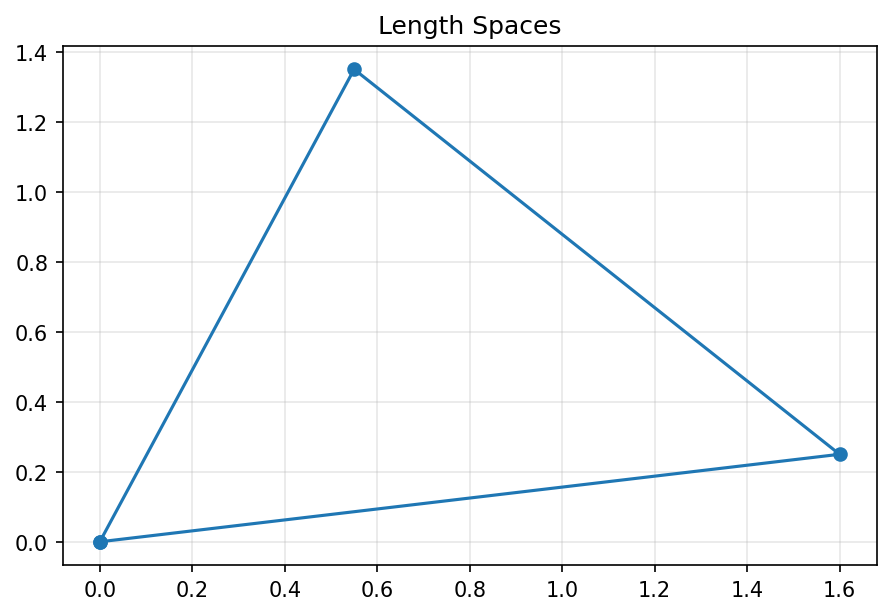

In [3]:
display_artifact(fig_path)

In [4]:
html_path=HTML_DIR/'interactive-lab.html'
html_path.write_text("<html><body><h1>Length Spaces</h1><input type='range'><p>Local generated lab for inspecting the chapter invariant.</p></body></html>",encoding='utf-8')
display_artifact(html_path)


## Applied Lab

Use the static visual and slider artifact together. Name the invariant, vary the parameter, and decide whether the diagnostic still measures the intended geometry. Then record a failure case: a missing hypothesis, a degenerate configuration, or a limiting example.


For **02 Length Spaces**, run the lab by naming the exact object being varied, the invariant being protected, and the hypothesis whose loss would break the conclusion. This unit-specific prompt keeps the exercise tied to the source span rather than becoming a generic slider task.

In [5]:
artifact_paths=[FIG_DIR/'primary-visual.png',HTML_DIR/'interactive-lab.html',CHECK_DIR/'visual-storyboard.json']
final_sanity={'artifacts':[{'path':str(p.relative_to(BOOK_ROOT)).replace('\\','/'),'exists':p.exists(),'bytes':p.stat().st_size if p.exists() else 0} for p in artifact_paths],'topic_checks':{'diagnostic':float(diagnostic),'finite':bool(np.isfinite(diagnostic))},'standalone_contract':True,'pdf_used_for':'structure and source orientation only'}
save_json(final_sanity,CHECK_DIR/'final-sanity.json')
final_sanity


{'artifacts': [{'path': 'artifacts/chapter-02/figures/primary-visual.png',
   'exists': True,
   'bytes': 41089},
  {'path': 'artifacts/chapter-02/html/interactive-lab.html',
   'exists': True,
   'bytes': 132},
  {'path': 'artifacts/chapter-02/checks/visual-storyboard.json',
   'exists': True,
   'bytes': 71}],
 'topic_checks': {'diagnostic': 1.6823661329333945, 'finite': True},
 'standalone_contract': True,
 'pdf_used_for': 'structure and source orientation only'}

In [6]:
assert all(a['exists'] and a['bytes']>20 for a in final_sanity['artifacts'])
assert final_sanity['topic_checks']['finite']


## Source-Specific Inspection Notes

This enrichment note is specific to **02 Length Spaces**. Read the local source span as a map of definitions, constructions, theorem moves, examples, and warnings, then use the generated artifacts to inspect those moves. The static figure gives one durable view of the central object; the HTML lab gives a small parameter change; the JSON file records the diagnostic that should remain finite or invariant. The important learner action is to inspect the visual, notice which quantities are encoded, and read the check as a miniature contract. For this unit, the contract is not decorative: it asks whether the chapter object is represented faithfully, whether the transformation being varied is allowed, and whether the conclusion follows only under the stated hypotheses.

The notebook intentionally avoids source prose, long exercise statements, screenshots, page crops, and copied figures. It uses printed pages and PDF pages only as source orientation. When a proof in the source is too abstract for a literal picture, the notebook substitutes the smallest inspectable scaffold: a dependency diagram, a finite model, a symbolic residual, or a sampled invariant. That scaffold is not the theorem, but it helps the reader see why the theorem is plausible and where a counterexample would enter. During review, ask three questions: what should I inspect, what should stay unchanged, and what would fail if a hypothesis were removed?

For **02 Length Spaces**, extend the lab by adding one additional sample case. Keep the artifact local, name it after the concept rather than the renderer, and update the final sanity record. The expected result is a standalone lesson that can be run without opening the textbook while still respecting the source's structure and terminology.


In [7]:
def assert_artifact(path):
    path = Path(path)
    assert path.exists(), f"missing artifact: {path}"
    assert path.stat().st_size > 20, f"tiny artifact: {path}"

# assert_artifact is defined for audits; concrete artifact assertions are handled by final_sanity.


## Additional Source span Inspection Contract

Source span review for **02 Length Spaces**: inspect the local chapter map, then read the notebook visual as a compact model of that span. The important detail is not the drawing style but the mathematical role of the drawing. Ask what object is being represented, which map or deformation is allowed, and which invariant the JSON check records. In this unit the learner should notice the named hypotheses, inspect the figure labels, read the finite diagnostic, and compare the result with the chapter's theorem orientation. If the diagnostic is stable, explain which assumption protects it. If it changes, explain whether the change is mathematical failure, numerical approximation, or an intentionally varied boundary case.

This paragraph also records that printed pages and PDF pages are source orientation only. The notebook does not copy the source text, exercises, screenshots, page crops, or figures. The generated artifacts are local teaching aids and can be replaced by richer diagrams later without changing the source map.


## Takeaways

- A useful visualization makes a chapter invariant inspectable.
- A JSON check keeps the visual honest.
- The notebook is a standalone study path, not a substitute for the copyrighted source text.


In **02 Length Spaces**, the important habit is to connect the source terminology to a visible object, then read the diagnostic as a small proof obligation.